# 05 — Model Validation & Early Exercise

Validates the three pricing engines from NB04 against observed market prices and analyses
the early exercise boundary for American puts on GOOG.

**Inputs**
- `data/processed/options_with_prices.csv` — output of NB04 (BSM, CRR, LSM prices)
- `config.toml`

**Outputs**
- `data/processed/options_with_validation.csv` — full dataset with validation columns
- `outputs/tables/notebook5_fit_summary.csv` — fit statistics by model
- `outputs/tables/notebook5_bid_ask_hit_rate.csv` — bid-ask containment rates
- `outputs/tables/notebook5_fit_by_moneyness.csv` — fit breakdown by moneyness bucket
- `outputs/tables/notebook5_fit_by_expiry.csv` — fit breakdown by expiry
- `outputs/plots/` — all validation plots

**Notebook flow**
1. Imports and configuration
2. Load priced dataset
3. Define moneyness buckets
4. Compute price errors (absolute and percentage)
5. Bid-ask containment check
6. Overall fit summary
7. Fit by option type (calls vs puts)
8. Fit by moneyness bucket
9. Fit by expiry
10. Model price vs market mid scatter plots
11. Residual distribution plots
12. Early exercise boundary (CRR)
13. Save all outputs
14. Final summary

## 1. Imports and configuration

In [1]:
# Standard library
import tomllib
from pathlib import Path

# Numerical and data libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"]      = True
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"]= 9

Path("outputs/plots").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

In [2]:
with open("config.toml", "rb") as f:
    config = tomllib.load(f)

ticker         = config["ticker"]
risk_free_rate = config["risk_free_rate"]
dividend_yield = config["dividend_yield"]

# Model labels used consistently throughout the notebook
MODELS = {
    "price_bsm": "BSM (European)",
    "price_crr": "CRR (American)",
    "price_lsm": "LSM (American)",
}

# Colour palette — consistent across all plots
MODEL_COLORS = {
    "price_bsm": "#2196F3",   # blue
    "price_crr": "#4CAF50",   # green
    "price_lsm": "#FF9800",   # orange
}

print("Ticker          :", ticker)
print("Risk-free rate  :", risk_free_rate)
print("Dividend yield  :", dividend_yield)

Ticker          : GOOG
Risk-free rate  : 0.045
Dividend yield  : 0.0


## 2. Load priced dataset

In [3]:
options = pd.read_csv("data/processed/options_with_prices.csv")
options["expiration"]    = pd.to_datetime(options["expiration"])
options["valuation_date"]= pd.to_datetime(options["valuation_date"])

numeric_cols = [
    "strike", "bid", "ask", "mid", "ttm", "spot",
    "log_moneyness", "iv_model", "iv_engine",
    "price_bsm", "price_crr", "price_lsm",
    "delta_bsm", "delta_crr", "eep_crr", "eep_lsm",
]
for col in numeric_cols:
    if col in options.columns:
        options[col] = pd.to_numeric(options[col], errors="coerce")

print("Dataset shape        :", options.shape)
print("Expiries             :", sorted(options["expiration"].dt.date.unique()))
print("Option types         :", options["option_type"].value_counts().to_dict())
print("NaN check (prices)   :")
for col in ["price_bsm", "price_crr", "price_lsm"]:
    print(f"  {col}: {options[col].isna().sum()} NaN")

options[["expiration", "option_type", "strike", "bid", "ask", "mid",
         "price_bsm", "price_crr", "price_lsm"]].head(8)

Dataset shape        : (181, 40)
Expiries             : [datetime.date(2026, 3, 27), datetime.date(2026, 4, 17), datetime.date(2026, 6, 18), datetime.date(2026, 9, 18), datetime.date(2027, 3, 19)]
Option types         : {'call': 101, 'put': 80}
NaN check (prices)   :
  price_bsm: 0 NaN
  price_crr: 0 NaN
  price_lsm: 0 NaN


,expiration,option_type,strike,bid,ask,mid,price_bsm,price_crr,price_lsm
0,2026-03-27,call,260.0,46.40,48.35,47.375,44.842729,44.842043,44.921166
1,2026-03-27,call,265.0,41.50,43.30,42.400,39.895511,39.894578,39.813829
2,2026-03-27,call,270.0,36.55,38.40,37.475,34.972789,34.970512,34.888971
3,2026-03-27,call,275.0,31.70,33.55,32.625,30.090705,30.089594,30.050166
4,2026-03-27,call,277.5,29.25,30.90,30.075,27.673223,27.670114,27.564395
5,2026-03-27,call,280.0,26.85,28.65,27.750,25.278268,25.278215,25.187922
6,2026-03-27,call,282.5,24.50,26.30,25.400,22.913159,22.914494,22.830996
7,2026-03-27,call,285.0,23.05,23.50,23.275,20.587548,20.589087,20.429071


## 3. Define moneyness buckets

We classify options into five moneyness buckets based on `log_moneyness = ln(K/S)`.
This is used throughout the notebook to break down fit quality by how far an option is
from the money.

| Bucket | log-moneyness range | Description |
|--------|--------------------|--------------|
| Deep ITM | < −0.10 | Strike well below spot |
| ITM | −0.10 to −0.03 | Strike moderately below spot |
| ATM | −0.03 to +0.03 | Near the money |
| OTM | +0.03 to +0.10 | Strike moderately above spot |
| Deep OTM | > +0.10 | Strike well above spot |

In [4]:
def moneyness_bucket(lm):
    """Assign a moneyness bucket label from log-moneyness."""
    if lm < -0.10:
        return "Deep ITM"
    elif lm < -0.03:
        return "ITM"
    elif lm <= 0.03:
        return "ATM"
    elif lm <= 0.10:
        return "OTM"
    else:
        return "Deep OTM"

options["moneyness_bucket"] = options["log_moneyness"].apply(moneyness_bucket)

# Ordered category so tables and plots sort correctly
BUCKET_ORDER = ["Deep ITM", "ITM", "ATM", "OTM", "Deep OTM"]
options["moneyness_bucket"] = pd.Categorical(
    options["moneyness_bucket"], categories=BUCKET_ORDER, ordered=True
)

print("Moneyness bucket distribution:")
print(options["moneyness_bucket"].value_counts().sort_index())

Moneyness bucket distribution:
moneyness_bucket
Deep ITM    40
ITM         45
ATM         37
OTM         42
Deep OTM    17
Name: count, dtype: int64


## 4. Compute price errors

Three error measures are computed for each model:

- **Absolute error** = model_price − mid  
- **Percentage error** = (model_price − mid) / mid × 100  
- **Absolute percentage error** = |percentage error|

Using the **mid price** as the reference. The bid-ask containment check in Section 5 tests
whether the model price falls within the quoted spread, which is a stricter and more
meaningful criterion than comparing to the mid alone.

In [5]:
for col in MODELS:
    base = col.replace("price_", "")          # bsm / crr / lsm
    options[f"err_{base}"]     = options[col] - options["mid"]
    options[f"pct_err_{base}"] = 100 * options[f"err_{base}"] / options["mid"]
    options[f"ape_{base}"]     = options[f"pct_err_{base}"].abs()

print("Error columns added:")
err_cols = [c for c in options.columns if c.startswith("err_") or
            c.startswith("pct_err_") or c.startswith("ape_")]
print(" ", err_cols)

options[["option_type", "strike", "mid",
         "price_bsm", "err_bsm", "pct_err_bsm",
         "price_crr", "err_crr",
         "price_lsm", "err_lsm"]].head(8).round(4)

Error columns added:
  ['err_bsm', 'pct_err_bsm', 'ape_bsm', 'err_crr', 'pct_err_crr', 'ape_crr', 'err_lsm', 'pct_err_lsm', 'ape_lsm']


,option_type,strike,mid,price_bsm,err_bsm,pct_err_bsm,price_crr,err_crr,price_lsm,err_lsm
0,call,260.0,47.375,44.8427,-2.5323,-5.3452,44.8420,-2.5330,44.9212,-2.4538
1,call,265.0,42.400,39.8955,-2.5045,-5.9068,39.8946,-2.5054,39.8138,-2.5862
2,call,270.0,37.475,34.9728,-2.5022,-6.6770,34.9705,-2.5045,34.8890,-2.5860
3,call,275.0,32.625,30.0907,-2.5343,-7.7680,30.0896,-2.5354,30.0502,-2.5748
4,call,277.5,30.075,27.6732,-2.4018,-7.9860,27.6701,-2.4049,27.5644,-2.5106
5,call,280.0,27.750,25.2783,-2.4717,-8.9071,25.2782,-2.4718,25.1879,-2.5621
6,call,282.5,25.400,22.9132,-2.4868,-9.7907,22.9145,-2.4855,22.8310,-2.5690
7,call,285.0,23.275,20.5875,-2.6875,-11.5465,20.5891,-2.6859,20.4291,-2.8459


## 5. Bid-ask containment check

A model price is **contained** within the bid-ask spread if:

    bid ≤ model_price ≤ ask

Containment is a stronger criterion than low absolute error: it means the model would
produce a price at which the option is actually tradeable. A high containment rate
is a key validation target for an industrial pricing engine.

In [6]:
for col in MODELS:
    base = col.replace("price_", "")
    options[f"in_spread_{base}"] = (
        (options[col] >= options["bid"]) &
        (options[col] <= options["ask"])
    )

# Overall containment rates
containment = {}
for col, label in MODELS.items():
    base = col.replace("price_", "")
    rate = options[f"in_spread_{base}"].mean() * 100
    containment[label] = round(rate, 2)

containment_series = pd.Series(containment, name="hit_rate_%")
print("=== BID-ASK CONTAINMENT RATES (all options) ===")
print(containment_series.to_string())

=== BID-ASK CONTAINMENT RATES (all options) ===
BSM (European)    23.20
CRR (American)    16.57
LSM (American)     8.84


In [7]:
# Containment by option type
hit_rows = []
for otype in ["call", "put", "all"]:
    subset = options if otype == "all" else options[options["option_type"] == otype]
    row = {"option_type": otype}
    for col, label in MODELS.items():
        base = col.replace("price_", "")
        row[label] = round(subset[f"in_spread_{base}"].mean() * 100, 1)
    row["n"] = len(subset)
    hit_rows.append(row)

hit_df = pd.DataFrame(hit_rows).set_index("option_type")
print("Bid-ask containment rate (%) by option type:")
hit_df

Bid-ask containment rate (%) by option type:


,BSM (European),CRR (American),LSM (American),n
option_type,,,,
call,19.8,19.8,5.0,101
put,27.5,12.5,13.8,80
all,23.2,16.6,8.8,181


## 6. Overall fit summary

Key statistics for each model across all 181 options.

In [8]:
summary_rows = []
for col, label in MODELS.items():
    base = col.replace("price_", "")
    errs = options[f"err_{base}"].dropna()
    pct  = options[f"pct_err_{base}"].dropna()
    ape  = options[f"ape_{base}"].dropna()
    hit  = options[f"in_spread_{base}"].mean() * 100

    summary_rows.append({
        "model"          : label,
        "mean_err"       : round(errs.mean(), 4),
        "mae"            : round(errs.abs().mean(), 4),
        "rmse"           : round(np.sqrt((errs**2).mean()), 4),
        "median_abs_err" : round(errs.abs().median(), 4),
        "max_abs_err"    : round(errs.abs().max(), 4),
        "mean_pct_err"   : round(pct.mean(), 2),
        "mape"           : round(ape.mean(), 2),
        "bid_ask_hit_%"  : round(hit, 1),
    })

fit_summary = pd.DataFrame(summary_rows).set_index("model")
print("=== OVERALL FIT SUMMARY ===")
fit_summary

=== OVERALL FIT SUMMARY ===


,mean_err,mae,rmse,median_abs_err,max_abs_err,mean_pct_err,mape,bid_ask_hit_%
model,,,,,,,,
BSM (European),-0.3788,0.8776,1.2508,0.5337,2.9049,0.60,7.20,23.2
CRR (American),-0.2016,1.0148,1.3725,0.7698,3.2981,1.24,7.73,16.6
LSM (American),-0.5264,1.1681,1.5609,0.8813,3.6089,-0.56,8.00,8.8


## 7. Fit by option type (calls vs puts)

BSM should fit calls well (no early exercise premium for GOOG with q=0).  
For puts, CRR and LSM should outperform BSM because they capture the early exercise premium.

In [9]:
type_rows = []
for otype in ["call", "put"]:
    sub = options[options["option_type"] == otype]
    for col, label in MODELS.items():
        base = col.replace("price_", "")
        errs = sub[f"err_{base}"].dropna()
        type_rows.append({
            "option_type": otype,
            "model"      : label,
            "n"          : len(sub),
            "mean_err"   : round(errs.mean(), 4),
            "mae"        : round(errs.abs().mean(), 4),
            "rmse"       : round(np.sqrt((errs**2).mean()), 4),
            "mape"       : round(sub[f"ape_{base}"].mean(), 2),
            "hit_%"      : round(sub[f"in_spread_{base}"].mean() * 100, 1),
        })

type_fit_df = pd.DataFrame(type_rows).set_index(["option_type", "model"])
print("Fit statistics by option type:")
type_fit_df

Fit statistics by option type:


n  mean_err     mae    rmse  mape  hit_%
option_type model                                                     
call        BSM (European)  101   -1.0648  1.1149  1.4837  8.37   19.8
            CRR (American)  101   -1.0595  1.1130  1.4810  8.28   19.8
            LSM (American)  101   -1.5011  1.5128  1.8659  9.44    5.0
put         BSM (European)   80    0.4874  0.5779  0.8719  5.73   27.5
            CRR (American)   80    0.8817  0.8908  1.2218  7.05   12.5
            LSM (American)   80    0.7041  0.7330  1.0569  6.17   13.8

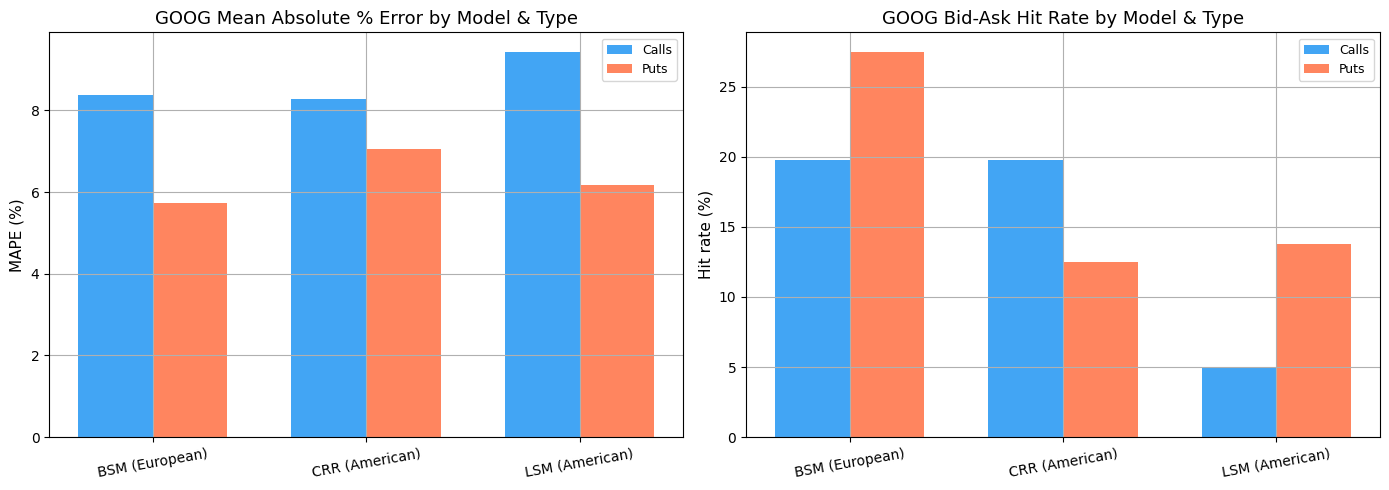

In [10]:
# Bar chart: MAPE and hit rate by model and option type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_labels = list(MODELS.values())
x = np.arange(len(model_labels))
width = 0.35

for ax, metric, title, ylabel in [
    (axes[0], "mape",  "Mean Absolute % Error by Model & Type", "MAPE (%)"),
    (axes[1], "hit_%", "Bid-Ask Hit Rate by Model & Type",      "Hit rate (%)"),
]:
    calls_vals = [type_fit_df.loc[("call", m), metric] for m in model_labels]
    puts_vals  = [type_fit_df.loc[("put",  m), metric] for m in model_labels]

    ax.bar(x - width/2, calls_vals, width, label="Calls", color="#2196F3", alpha=0.85)
    ax.bar(x + width/2, puts_vals,  width, label="Puts",  color="#FF7043", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=10)
    ax.set_title(f"{ticker} {title}")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig("outputs/plots/nb05_fit_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Fit by moneyness bucket

Model fit typically varies significantly across moneyness:
- **ATM** options are most liquid and should have the tightest spreads → highest hit rates
- **Deep ITM/OTM** options are less liquid, wider spreads, noisier IVs

In [11]:
moneyness_rows = []
for bucket in BUCKET_ORDER:
    sub = options[options["moneyness_bucket"] == bucket]
    if len(sub) == 0:
        continue
    for col, label in MODELS.items():
        base = col.replace("price_", "")
        errs = sub[f"err_{base}"].dropna()
        moneyness_rows.append({
            "moneyness_bucket": bucket,
            "model"           : label,
            "n"               : len(sub),
            "mean_err"        : round(errs.mean(), 4),
            "mae"             : round(errs.abs().mean(), 4),
            "mape"            : round(sub[f"ape_{base}"].mean(), 2),
            "hit_%"           : round(sub[f"in_spread_{base}"].mean() * 100, 1),
        })

moneyness_fit_df = pd.DataFrame(moneyness_rows).set_index(["moneyness_bucket", "model"])
print("Fit statistics by moneyness bucket:")
moneyness_fit_df

Fit statistics by moneyness bucket:


n  mean_err     mae   mape  hit_%
moneyness_bucket model                                             
Deep ITM         BSM (European)  40   -0.9265  0.9396   3.27   42.5
                 CRR (American)  40   -0.8283  1.0156   3.71   25.0
                 LSM (American)  40   -1.1713  1.3003   4.63   20.0
ITM              BSM (European)  45   -0.9442  1.1316   6.04   17.8
                 CRR (American)  45   -0.8635  1.2044   6.56   13.3
                 LSM (American)  45   -1.1684  1.4213   6.51   11.1
ATM              BSM (European)  37   -0.1645  1.0260  11.65   13.5
                 CRR (American)  37    0.0023  1.1773  12.36    8.1
                 LSM (American)  37   -0.2903  1.2333  12.31    2.7
OTM              BSM (European)  42    0.2720  0.5641   8.17   16.7
                 CRR (American)  42    0.5471  0.7817   8.73   19.0
                 LSM (American)  42    0.2146  0.8387   9.30    2.4
Deep OTM         BSM (European)  17    0.3326  0.5103   7.46   29.4
                 CRR (American)  17    0.7321  0.7333   7.77   17.6
                 LSM (American)  17    0.3457  0.8593   7.25    5.9

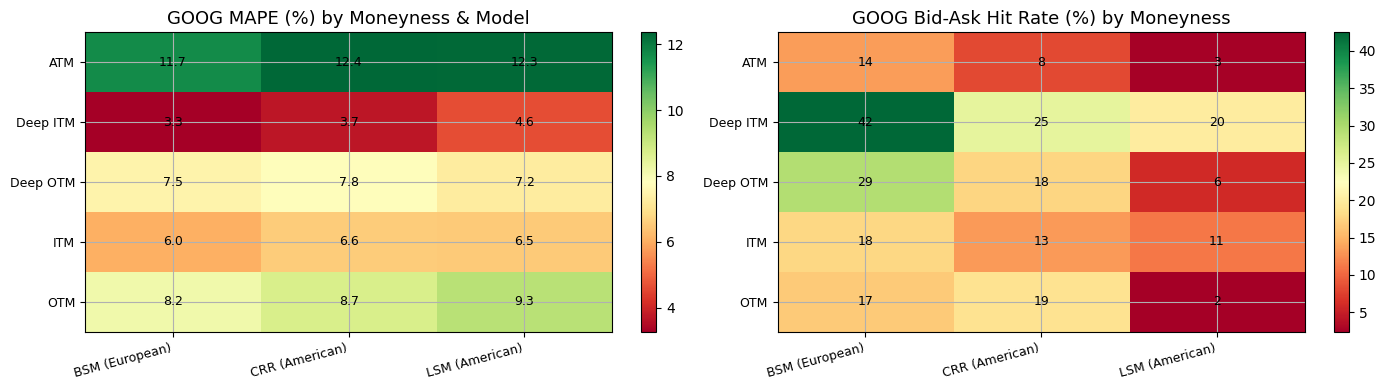

In [12]:
# Heatmap: MAPE by moneyness bucket × model
mape_pivot = moneyness_fit_df["mape"].unstack(level="model")
hit_pivot  = moneyness_fit_df["hit_%"].unstack(level="model")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title, fmt in [
    (axes[0], mape_pivot, "MAPE (%) by Moneyness & Model",       ".1f"),
    (axes[1], hit_pivot,  "Bid-Ask Hit Rate (%) by Moneyness",   ".0f"),
]:
    im = ax.imshow(data.values, aspect="auto", cmap="RdYlGn",
                   vmin=data.values.min(), vmax=data.values.max())
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=15, ha="right", fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_title(f"{ticker} {title}")
    plt.colorbar(im, ax=ax, fraction=0.04)
    # Annotate cells
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        fontsize=9, color="black")

plt.tight_layout()
plt.savefig("outputs/plots/nb05_fit_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Fit by expiry

Short-dated options tend to have wider IVs and noisier prices relative to their premium.
Longer-dated options are smoother but the absolute price errors are larger.

In [13]:
expiry_rows = []
for expiry, grp in options.groupby("expiration"):
    for col, label in MODELS.items():
        base = col.replace("price_", "")
        errs = grp[f"err_{base}"].dropna()
        expiry_rows.append({
            "expiry"  : expiry.date(),
            "ttm"     : round(grp["ttm"].iloc[0], 4),
            "model"   : label,
            "n"       : len(grp),
            "mean_err": round(errs.mean(), 4),
            "mae"     : round(errs.abs().mean(), 4),
            "mape"    : round(grp[f"ape_{base}"].mean(), 2),
            "hit_%"   : round(grp[f"in_spread_{base}"].mean() * 100, 1),
        })

expiry_fit_df = pd.DataFrame(expiry_rows).set_index(["expiry", "model"])
print("Fit statistics by expiry:")
expiry_fit_df

Fit statistics by expiry:


ttm   n  mean_err     mae   mape  hit_%
expiry     model                                                     
2026-03-27 BSM (European)  0.0274  51   -0.6224  0.9826  14.96   17.6
           CRR (American)  0.0274  51   -0.6176  0.9868  15.02   13.7
           LSM (American)  0.0274  51   -0.6829  1.0159  14.90   17.6
2026-04-17 BSM (European)  0.0849  34   -0.3863  1.1391   9.11    5.9
           CRR (American)  0.0849  34   -0.3420  1.1806   9.39    5.9
           LSM (American)  0.0849  34   -0.5098  1.2812   9.64    0.0
2026-06-18 BSM (European)  0.2548  36   -0.2043  1.0523   4.11    8.3
           CRR (American)  0.2548  36   -0.0410  1.2039   4.74    5.6
           LSM (American)  0.2548  36   -0.4407  1.3844   5.06    8.3
2026-09-18 BSM (European)  0.5068  34   -0.2822  0.7239   2.03   14.7
           CRR (American)  0.5068  34    0.0228  1.0044   3.00    8.8
           LSM (American)  0.5068  34   -0.4688  1.1807   3.38    2.9
2027-03-19 BSM (European)  1.0055  26   -0.2588  0.2885   0.53   88.5
           CRR (American)  1.0055  26    0.2824  0.6048   1.60   61.5
           LSM (American)  1.0055  26   -0.4351  1.0030   2.40   11.5

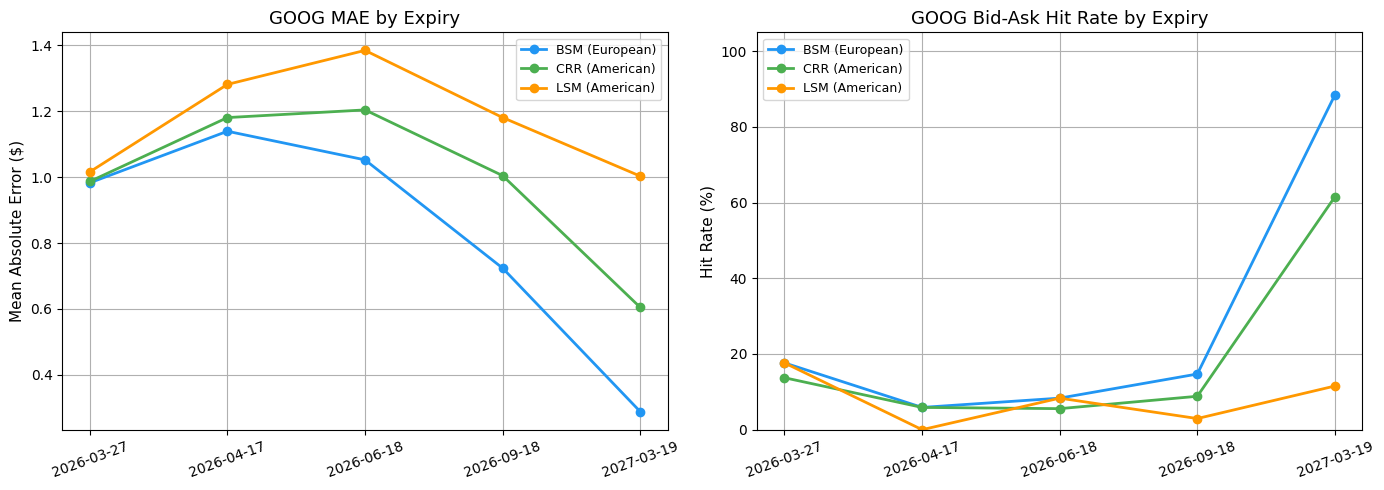

In [14]:
# Line chart: MAE and hit rate across expiries for each model
expiries = sorted(options["expiration"].unique())
expiry_labels = [pd.Timestamp(e).strftime("%Y-%m-%d") for e in expiries]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, label in MODELS.items():
    base  = col.replace("price_", "")
    color = MODEL_COLORS[col]
    maes  = []
    hits  = []
    for expiry in expiries:
        grp  = options[options["expiration"] == expiry]
        maes.append(grp[f"err_{base}"].abs().mean())
        hits.append(grp[f"in_spread_{base}"].mean() * 100)
    axes[0].plot(expiry_labels, maes, marker="o", linewidth=2,
                 label=label, color=color)
    axes[1].plot(expiry_labels, hits, marker="o", linewidth=2,
                 label=label, color=color)

axes[0].set_title(f"{ticker} MAE by Expiry")
axes[0].set_ylabel("Mean Absolute Error ($)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

axes[1].set_title(f"{ticker} Bid-Ask Hit Rate by Expiry")
axes[1].set_ylabel("Hit Rate (%)")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/plots/nb05_fit_by_expiry.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Model price vs market mid scatter plots

Each model's price is plotted against the market mid on a 45-degree line chart.
Points on the line = perfect fit. Points above/below the line indicate systematic over/under-pricing.
The bid and ask are shown as vertical error bars to give context for whether deviations
are within the tradeable spread.

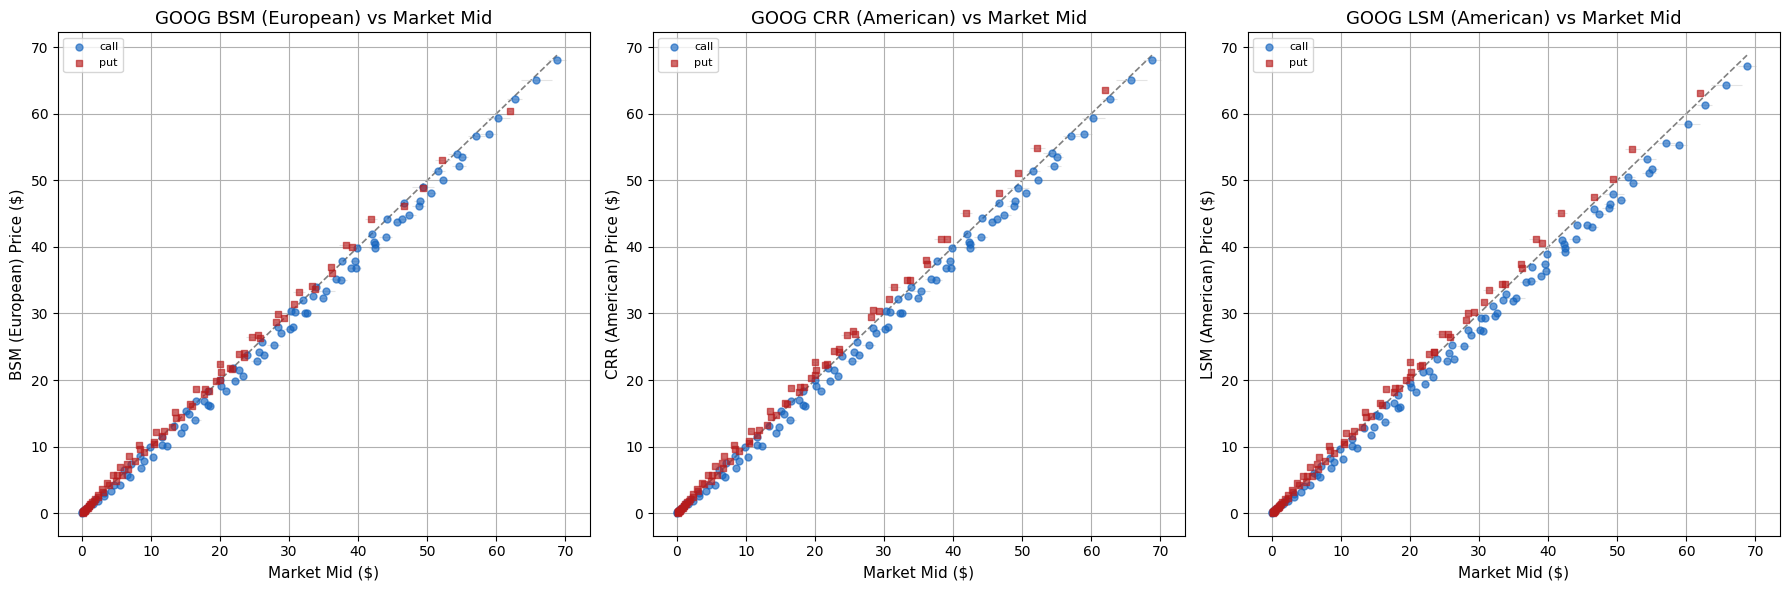

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, label) in zip(axes, MODELS.items()):
    color = MODEL_COLORS[col]

    # Plot bid-ask range as thin vertical error bars
    half_spread = (options["ask"] - options["bid"]) / 2
    ax.errorbar(
        options["mid"], options[col],
        xerr=half_spread,
        fmt="none", ecolor="lightgray", elinewidth=0.8, alpha=0.6, zorder=1
    )

    # Colour points by option type
    for otype, marker, oc in [("call", "o", "#1565C0"), ("put", "s", "#B71C1C")]:
        sub = options[options["option_type"] == otype]
        ax.scatter(sub["mid"], sub[col], s=25, alpha=0.65,
                   marker=marker, color=oc, label=otype, zorder=2)

    # 45-degree line
    lo = min(options["mid"].min(), options[col].min())
    hi = max(options["mid"].max(), options[col].max())
    ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.2, zorder=0)

    ax.set_xlabel("Market Mid ($)")
    ax.set_ylabel(f"{label} Price ($)")
    ax.set_title(f"{ticker} {label} vs Market Mid")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/plots/nb05_price_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Residual distribution plots

The distribution of price errors (model − mid) reveals:
- **Bias**: is the mean error materially different from zero?
- **Spread**: how wide is the error distribution?
- **Skew/tails**: are errors symmetric or does one tail dominate?

Percentage errors are also plotted to control for the wide range of option prices.

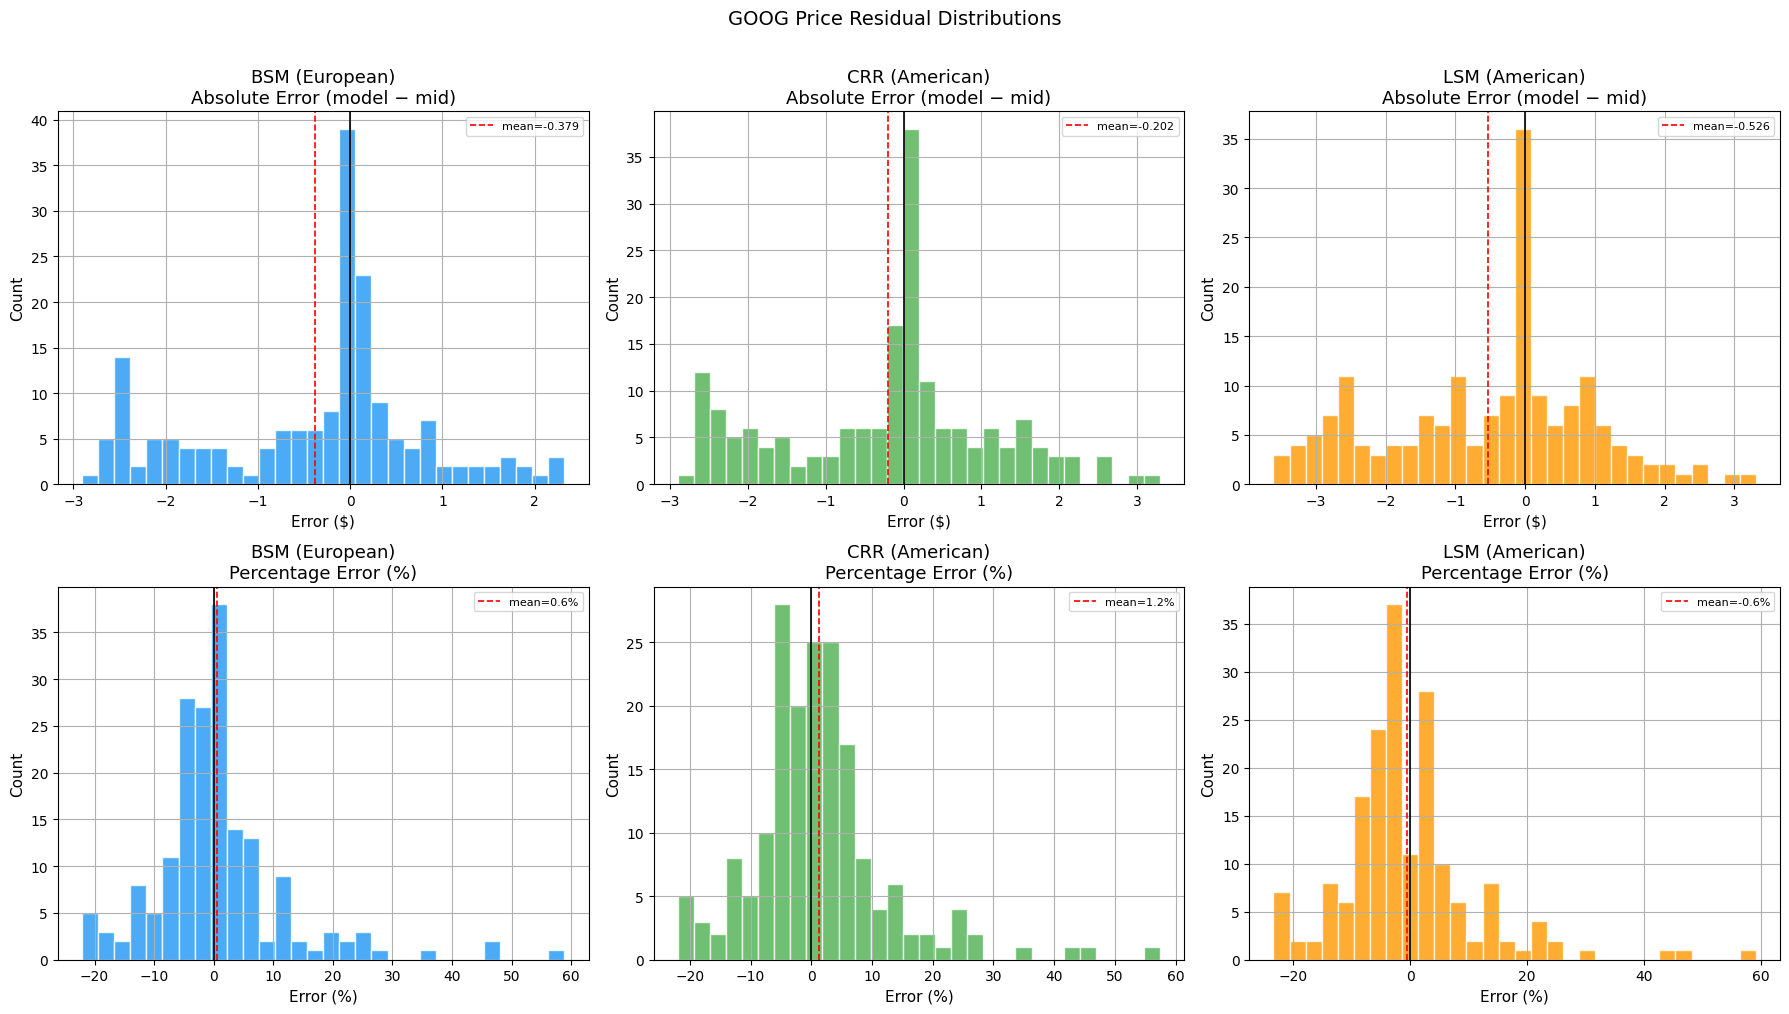

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for j, (col, label) in enumerate(MODELS.items()):
    base  = col.replace("price_", "")
    color = MODEL_COLORS[col]

    # Row 0: absolute error histogram
    errs = options[f"err_{base}"].dropna()
    axes[0, j].hist(errs, bins=30, color=color, alpha=0.80, edgecolor="white")
    axes[0, j].axvline(0,           color="black", linewidth=1.2, linestyle="-")
    axes[0, j].axvline(errs.mean(), color="red",   linewidth=1.2, linestyle="--",
                       label=f"mean={errs.mean():.3f}")
    axes[0, j].set_title(f"{label}\nAbsolute Error (model − mid)")
    axes[0, j].set_xlabel("Error ($)")
    axes[0, j].set_ylabel("Count")
    axes[0, j].legend(fontsize=8)

    # Row 1: percentage error histogram
    pct = options[f"pct_err_{base}"].dropna()
    axes[1, j].hist(pct, bins=30, color=color, alpha=0.80, edgecolor="white")
    axes[1, j].axvline(0,          color="black", linewidth=1.2, linestyle="-")
    axes[1, j].axvline(pct.mean(), color="red",   linewidth=1.2, linestyle="--",
                       label=f"mean={pct.mean():.1f}%")
    axes[1, j].set_title(f"{label}\nPercentage Error (%)")
    axes[1, j].set_xlabel("Error (%)")
    axes[1, j].set_ylabel("Count")
    axes[1, j].legend(fontsize=8)

plt.suptitle(f"{ticker} Price Residual Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/plots/nb05_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

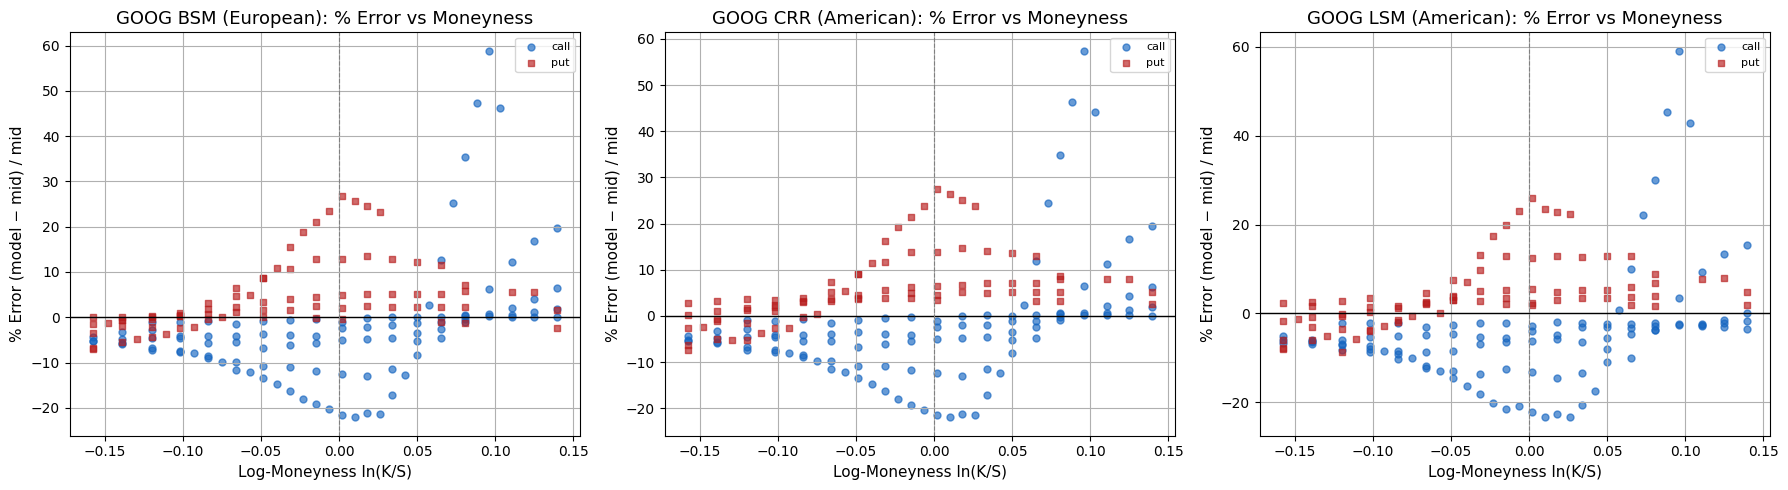

In [17]:
# Error vs log-moneyness: reveals whether mis-pricing is concentrated
# at one end of the smile (e.g. deep OTM options where IV is least reliable)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, MODELS.items()):
    base  = col.replace("price_", "")
    color = MODEL_COLORS[col]

    for otype, marker, oc in [("call", "o", "#1565C0"), ("put", "s", "#B71C1C")]:
        sub = options[options["option_type"] == otype]
        ax.scatter(sub["log_moneyness"], sub[f"pct_err_{base}"],
                   s=25, alpha=0.65, marker=marker, color=oc, label=otype)

    ax.axhline(0, color="black", linewidth=1.0, linestyle="-")
    ax.axvline(0, color="gray",  linewidth=0.8, linestyle="--")
    ax.set_xlabel("Log-Moneyness ln(K/S)")
    ax.set_ylabel("% Error (model − mid) / mid")
    ax.set_title(f"{ticker} {label}: % Error vs Moneyness")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/plots/nb05_error_vs_moneyness.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Early exercise boundary (CRR)

The **early exercise boundary** S*(t) is the critical spot price below which it becomes
optimal to exercise an American put immediately rather than hold it.

At each time step in the CRR tree, the early exercise decision is:
- Exercise if intrinsic value > continuation value
- The boundary S*(t) is the highest spot price at which this is true

We recover S*(t) by scanning the CRR tree backward and recording the boundary node
at each time step. This is computed for a representative ATM put at each available expiry.

**Key properties to expect:**
- S*(T) = K at expiry (by continuity)
- S*(t) < K for all t < T (boundary is below the strike)
- S*(t) is non-increasing as t approaches T
- Higher volatility → lower boundary (higher option value makes it less attractive to exercise early)

In [18]:
def crr_early_exercise_boundary(S, K, T, r, sigma, q=0.0, N=200):
    """
    Compute the early exercise boundary for an American put via CRR.

    Returns
    -------
    times   : np.ndarray  time points t in [0, T] (length N+1)
    boundary: np.ndarray  critical spot price S*(t) at each time point
                          NaN where no early exercise is optimal at that step
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0 or N < 1:
        return None, None

    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    disc = np.exp(-r * dt)
    p    = (np.exp((r - q) * dt) - d) / (u - d)

    if not (0 < p < 1):
        return None, None

    # Build full asset price tree: price[i, j] = S * u^j * d^(i-j)
    # i = time step, j = number of up moves
    asset = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            asset[i, j] = S * (u ** j) * (d ** (i - j))

    # Terminal payoffs
    V = np.maximum(K - asset[N, :N+1], 0.0)

    boundary = np.full(N + 1, np.nan)
    # At expiry, boundary is K (highest S where put has positive intrinsic value)
    boundary[N] = K

    # Backward induction — record the critical node at each time step
    for i in range(N - 1, -1, -1):
        V_cont = disc * (p * V[1:i+2] + (1 - p) * V[0:i+1])
        S_i    = asset[i, :i+1]
        intrinsic = np.maximum(K - S_i, 0.0)
        V = np.maximum(V_cont, intrinsic)

        # Boundary: highest S where early exercise is optimal
        exercise = intrinsic > V_cont
        if exercise.any():
            # The boundary is the highest spot price where we exercise
            boundary_nodes = S_i[exercise]
            boundary[i] = boundary_nodes.max()

    times = np.linspace(0, T, N + 1)
    return times, boundary

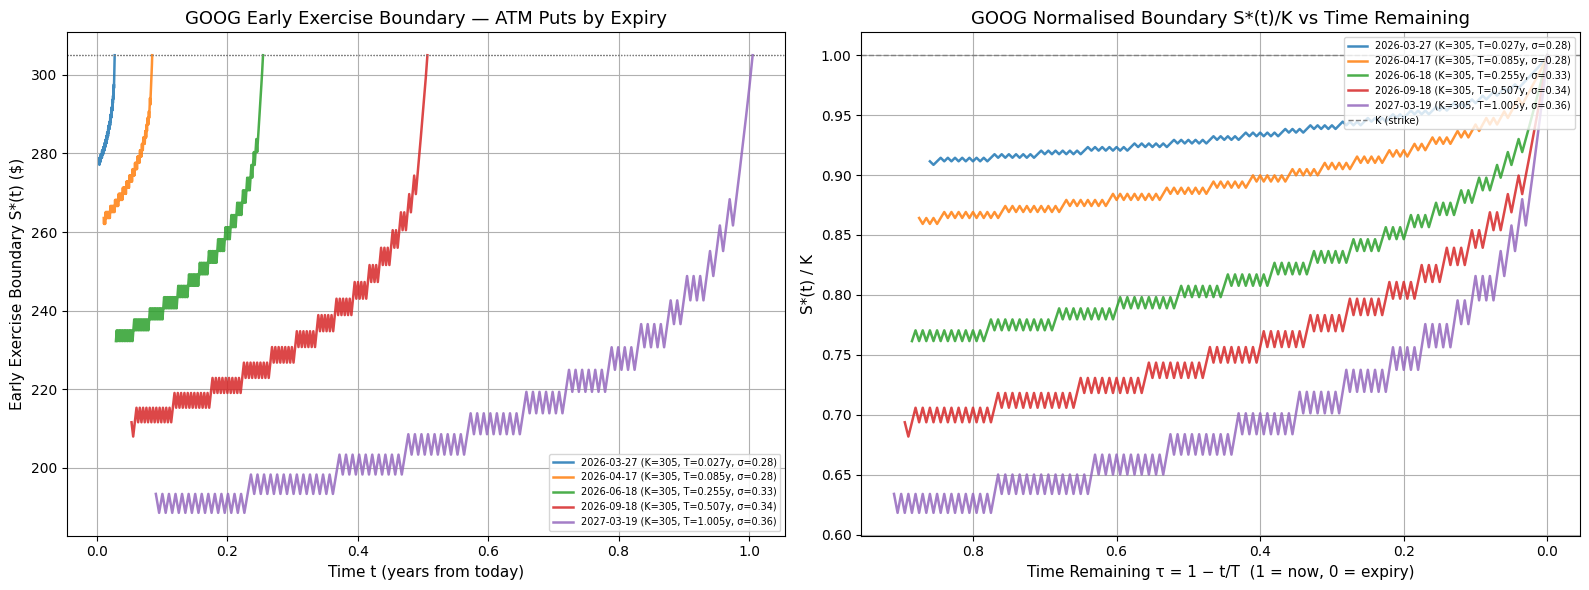

Early exercise boundary summary:


,expiry,K,T,iv_engine,S*_at_t0,S*_at_tT,S*_min,S*_over_K_at_t0
0,2026-03-27,305.0,0.0274,0.2771,278.00,305.0,277.10,0.9115
1,2026-04-17,305.0,0.0849,0.2797,263.57,305.0,262.06,0.8642
2,2026-06-18,305.0,0.2548,0.3297,232.24,305.0,232.24,0.7614
3,2026-09-18,305.0,0.5068,0.3441,211.58,305.0,207.95,0.6937
4,2027-03-19,305.0,1.0055,0.3557,193.35,305.0,188.53,0.6339


In [19]:
# Compute boundary for one representative near-ATM put per expiry
puts = options[options["option_type"] == "put"].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

boundary_rows = []

for expiry, grp in puts.groupby("expiration"):
    # Select the put with log-moneyness closest to 0 (most ATM)
    row = grp.iloc[(grp["log_moneyness"].abs()).argsort()].iloc[0]
    S_   = row["spot"]
    K_   = row["strike"]
    T_   = row["ttm"]
    sig_ = row["iv_engine"]

    times, boundary = crr_early_exercise_boundary(
        S_, K_, T_, risk_free_rate, sig_, q=dividend_yield, N=200
    )
    if times is None:
        continue

    # Normalise time axis to [0, 1] for comparison across expiries
    label = f"{expiry.date()} (K={K_:.0f}, T={T_:.3f}y, σ={sig_:.2f})"
    axes[0].plot(times, boundary, linewidth=1.8, alpha=0.85, label=label)
    axes[0].axhline(K_, color="gray", linestyle=":", linewidth=0.8)

    # Normalised time-to-expiry (1 = now, 0 = expiry)
    tau = 1.0 - times / T_
    boundary_normalised = boundary / K_
    axes[1].plot(tau, boundary_normalised, linewidth=1.8, alpha=0.85, label=label)

    # Store for table
    valid = ~np.isnan(boundary)
    if valid.any():
        boundary_rows.append({
            "expiry"         : expiry.date(),
            "K"              : K_,
            "T"              : round(T_, 4),
            "iv_engine"      : round(sig_, 4),
            "S*_at_t0"       : round(float(boundary[valid][0]), 2),
            "S*_at_tT"       : round(float(boundary[valid][-1]), 2),
            "S*_min"         : round(float(np.nanmin(boundary)), 2),
            "S*_over_K_at_t0": round(float(boundary[valid][0]) / K_, 4),
        })

# Left: boundary in dollar terms
axes[0].set_xlabel("Time t (years from today)")
axes[0].set_ylabel("Early Exercise Boundary S*(t) ($)")
axes[0].set_title(f"{ticker} Early Exercise Boundary — ATM Puts by Expiry")
axes[0].legend(fontsize=7, loc="lower right")

# Right: boundary normalised by strike (S*/K) vs tau = time remaining
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="K (strike)")
axes[1].set_xlabel("Time Remaining τ = 1 − t/T  (1 = now, 0 = expiry)")
axes[1].set_ylabel("S*(t) / K")
axes[1].set_title(f"{ticker} Normalised Boundary S*(t)/K vs Time Remaining")
axes[1].invert_xaxis()    # left = now, right = expiry
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/plots/nb05_early_exercise_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

boundary_df = pd.DataFrame(boundary_rows)
print("Early exercise boundary summary:")
boundary_df

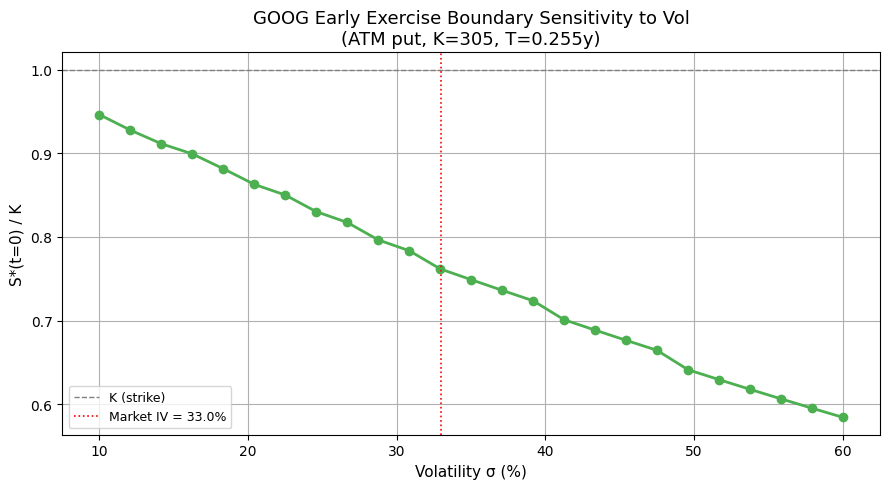

As expected: higher vol → lower early exercise boundary (more valuable to keep holding).


In [20]:
# Boundary sensitivity: how does S*(t=0)/K vary with volatility?
# Use the medium-term ATM put and sweep sigma.
medium_put = puts[
    (puts["days_to_expiry"] > 60) & (puts["days_to_expiry"] <= 150)
].iloc[(puts[
    (puts["days_to_expiry"] > 60) & (puts["days_to_expiry"] <= 150)
]["log_moneyness"].abs()).argsort()].iloc[0]

sigma_grid = np.linspace(0.10, 0.60, 25)
s_star_t0  = []

for sig in sigma_grid:
    times, bnd = crr_early_exercise_boundary(
        medium_put["spot"], medium_put["strike"],
        medium_put["ttm"], risk_free_rate, sig,
        q=dividend_yield, N=200
    )
    if times is not None:
        valid = ~np.isnan(bnd)
        s_star_t0.append(bnd[valid][0] / medium_put["strike"] if valid.any() else np.nan)
    else:
        s_star_t0.append(np.nan)

plt.figure(figsize=(9, 5))
plt.plot(sigma_grid * 100, s_star_t0, marker="o", linewidth=2, color="#4CAF50")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="K (strike)")
plt.axvline(medium_put["iv_engine"] * 100, color="red", linestyle=":",
            linewidth=1.2, label=f"Market IV = {medium_put['iv_engine']*100:.1f}%")
plt.xlabel("Volatility σ (%)")
plt.ylabel("S*(t=0) / K")
plt.title(
    f"{ticker} Early Exercise Boundary Sensitivity to Vol\n"
    f"(ATM put, K={medium_put['strike']:.0f}, T={medium_put['ttm']:.3f}y)"
)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/plots/nb05_boundary_vs_vol.png", dpi=150, bbox_inches="tight")
plt.show()
print("As expected: higher vol → lower early exercise boundary (more valuable to keep holding).")

## 13. Save all outputs

In [21]:
# --- Full validated dataset ---
options.to_csv("data/processed/options_with_validation.csv", index=False)
print("Saved: data/processed/options_with_validation.csv")

# --- Fit summary tables ---
fit_summary.to_csv("outputs/tables/notebook5_fit_summary.csv")
print("Saved: outputs/tables/notebook5_fit_summary.csv")

hit_df.to_csv("outputs/tables/notebook5_bid_ask_hit_rate.csv")
print("Saved: outputs/tables/notebook5_bid_ask_hit_rate.csv")

moneyness_fit_df.to_csv("outputs/tables/notebook5_fit_by_moneyness.csv")
print("Saved: outputs/tables/notebook5_fit_by_moneyness.csv")

expiry_fit_df.to_csv("outputs/tables/notebook5_fit_by_expiry.csv")
print("Saved: outputs/tables/notebook5_fit_by_expiry.csv")

# --- Early exercise boundary summary ---
boundary_df.to_csv("outputs/tables/notebook5_early_exercise_boundary.csv", index=False)
print("Saved: outputs/tables/notebook5_early_exercise_boundary.csv")

Saved: data/processed/options_with_validation.csv
Saved: outputs/tables/notebook5_fit_summary.csv
Saved: outputs/tables/notebook5_bid_ask_hit_rate.csv
Saved: outputs/tables/notebook5_fit_by_moneyness.csv
Saved: outputs/tables/notebook5_fit_by_expiry.csv
Saved: outputs/tables/notebook5_early_exercise_boundary.csv


## 14. Final summary

In [22]:
# Best model per metric
best_mae     = fit_summary["mae"].idxmin()
best_mape    = fit_summary["mape"].idxmin()
best_hit     = fit_summary["bid_ask_hit_%"].idxmax()
least_biased = fit_summary["mean_err"].abs().idxmin()

final_summary = pd.Series({
    "ticker"               : ticker,
    "n_options"            : len(options),
    "n_calls"              : int((options["option_type"] == "call").sum()),
    "n_puts"               : int((options["option_type"] == "put").sum()),
    # BSM
    "bsm_mae"              : fit_summary.loc["BSM (European)", "mae"],
    "bsm_mape"             : fit_summary.loc["BSM (European)", "mape"],
    "bsm_hit_%"            : fit_summary.loc["BSM (European)", "bid_ask_hit_%"],
    # CRR
    "crr_mae"              : fit_summary.loc["CRR (American)", "mae"],
    "crr_mape"             : fit_summary.loc["CRR (American)", "mape"],
    "crr_hit_%"            : fit_summary.loc["CRR (American)", "bid_ask_hit_%"],
    # LSM
    "lsm_mae"              : fit_summary.loc["LSM (American)", "mae"],
    "lsm_mape"             : fit_summary.loc["LSM (American)", "mape"],
    "lsm_hit_%"            : fit_summary.loc["LSM (American)", "bid_ask_hit_%"],
    # Winners
    "best_model_mae"       : best_mae,
    "best_model_mape"      : best_mape,
    "best_model_hit_rate"  : best_hit,
    "least_biased_model"   : least_biased,
})

final_summary.to_csv("outputs/tables/notebook5_final_summary.csv", header=False)
print("Saved: outputs/tables/notebook5_final_summary.csv")

print()
print("=" * 55)
print("NB05 COMPLETE — MODEL VALIDATION SUMMARY")
print("=" * 55)
final_summary

Saved: outputs/tables/notebook5_final_summary.csv

NB05 COMPLETE — MODEL VALIDATION SUMMARY


ticker                           GOOG
n_options                         181
n_calls                           101
n_puts                             80
bsm_mae                        0.8776
bsm_mape                          7.2
bsm_hit_%                        23.2
crr_mae                        1.0148
crr_mape                         7.73
crr_hit_%                        16.6
lsm_mae                        1.1681
lsm_mape                          8.0
lsm_hit_%                         8.8
best_model_mae         BSM (European)
best_model_mape        BSM (European)
best_model_hit_rate    BSM (European)
least_biased_model     CRR (American)
dtype: object